# GoalLab Stage 05: Learn stochastic investigation policies

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 04](04_dqn.ipynb) · [Stage 06](06_ppo.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/apply-theory/05_policy_gradient.ipynb)

**Build:** learn stochastic evidence policies directly and compare a full-return estimator with a one-step critic.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 05](../../../notebooks/05_policy_gradient.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Derive log-probability weighting; distinguish a critic from a verifier; explain stochastic deployment outcomes.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: credit comes from an action's log probability

For a categorical policy, increasing an action's log probability changes all normalized probabilities. A positive advantage increases the sampled action's probability under gradient descent on the negative objective. The advantage must be detached from the actor update.

A state baseline subtracts the same quantity regardless of which action was sampled. It can reduce variance without changing the expected policy gradient. A one-step critic introduces bootstrapping as well, so comparing it with REINFORCE changes more than just baseline variance.

In [2]:
logits=torch.tensor([0.,0.],requires_grad=True)
dist=torch.distributions.Categorical(logits=logits)
advantage=torch.tensor(.8)
loss=-dist.log_prob(torch.tensor(0))*advantage
loss.backward()
after=(logits-.1*logits.grad).softmax(-1)
print('Gradient:',logits.grad.tolist(),'Probabilities after one step:',after.detach().tolist())
assert after[0]>.5

Gradient: [-0.4000000059604645, 0.4000000059604645] Probabilities after one step: [0.5199893712997437, 0.4800106883049011]


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
def network(outputs):
    return nn.Sequential(nn.Linear(7, 32), nn.Tanh(), nn.Linear(32, outputs))


def train_policy(method='PPO', seed=7, episodes=600):
    if method not in {'REINFORCE', 'Actor-Critic', 'PPO'} or episodes % 24:
        raise ValueError('Supported policy method and a multiple of 24 episodes required')
    torch.manual_seed(seed)
    env, rng = EvidenceMDP(), np.random.default_rng(seed)
    features = torch.tensor(env.features())
    actor, critic = network(2), network(1)
    params = list(actor.parameters()) + ([] if method == 'REINFORCE' else list(critic.parameters()))
    optimizer = torch.optim.Adam(params, lr=.01 if method != 'PPO' else .004)
    history = []
    for update in range(episodes // 24):
        batch = []
        for _ in range(24):
            s = env.start_index
            for _ in range(4):
                with torch.no_grad():
                    dist = Categorical(logits=actor(features[s]))
                    a = dist.sample()
                    logp, value = dist.log_prob(a), critic(features[s]).squeeze()
                ns, r, done = env.step(s, int(a), rng)
                batch.append((s, int(a), r, float(logp), float(value)))
                s = ns
        states = torch.tensor([b[0] for b in batch])
        actions = torch.tensor([b[1] for b in batch])
        rewards = torch.tensor([b[2] for b in batch]).reshape(24, 4)
        old_logp = torch.tensor([b[3] for b in batch])
        values = torch.tensor([b[4] for b in batch]).reshape(24, 4)
        next_values = torch.cat([values[:, 1:], torch.zeros(24, 1)], dim=1)
        delta = rewards + next_values - values
        returns = torch.flip(torch.cumsum(torch.flip(rewards, [1]), 1), [1])
        if method == 'REINFORCE':
            advantage, targets = returns.flatten(), returns.flatten()
        elif method == 'Actor-Critic':
            advantage, targets = delta.flatten(), (rewards + next_values).flatten()
        else:
            gae, carry = torch.zeros_like(values), torch.zeros(24)
            for t in reversed(range(4)):
                carry = delta[:, t] + .95 * carry
                gae[:, t] = carry
            targets, advantage = (gae + values).flatten(), gae.flatten()
            advantage = (advantage - advantage.mean()) / (advantage.std(unbiased=False) + 1e-8)
        for _ in range(4 if method == 'PPO' else 1):
            dist = Categorical(logits=actor(features[states]))
            logp = dist.log_prob(actions)
            if method == 'PPO':
                ratio = (logp - old_logp).exp()
                actor_loss = -torch.minimum(ratio * advantage, ratio.clamp(.8, 1.2) * advantage).mean()
            else:
                actor_loss = -(logp * advantage).mean()
            loss = actor_loss - .01 * dist.entropy().mean()
            if method != 'REINFORCE':
                loss += .5 * nn.functional.mse_loss(critic(features[states]).squeeze(1), targets)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1); optimizer.step()
        with torch.no_grad():
            policy = actor(features).softmax(-1).numpy()
        history.append(((update + 1) * 24 * 4, env.values(policy)[0][env.start_index]))
    return {'env': env, 'policy': policy, 'model': actor, 'history': np.array(history)}

## 1. REINFORCE and actor-critic

REINFORCE weights action log probabilities by the complete episode return. Actor-critic uses detached one-step TD advantages and learns a value predictor. Both collect 24 complete episodes under a fixed actor per update. Entropy regularization discourages premature collapse.

The critic is a learned forecast of return; it is not the final evidence checker.

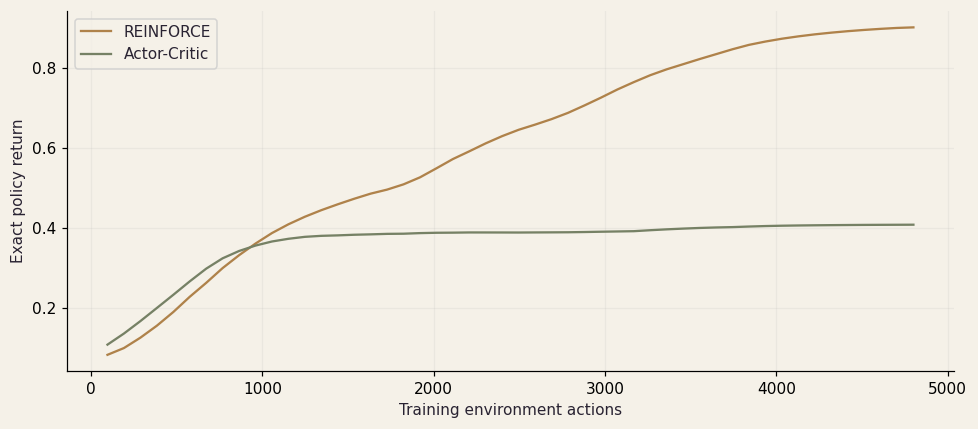

| Controller | Exact return | Held-out briefing success | Calls/case |
|---|---|---|---|
| REINFORCE | 0.903 | 99.0% | 4.0 |
| Actor-Critic | 0.409 | 44.0% | 4.0 |

In [4]:
runs = {m:train_policy(m,7,1200) for m in ['REINFORCE','Actor-Critic']}
learning_plot(runs); report_policies(runs)

## 2. Inspect stochastic decisions

A policy can retain some chance of claiming completion or citing the wrong source. Evaluate the actual stochastic distribution, not only argmax actions.

In [5]:
env = runs['Actor-Critic']['env']
table(['State','P(action 0)','P(action 1)'], [[s,*runs['Actor-Critic']['policy'][i].round(3)] for i,s in enumerate(env.states) if s[0]==3][:8])

| State | P(action 0) | P(action 1) |
|---|---|---|
| (3, 1, 0, 0) | 0.996 | 0.004 |
| (3, 1, 0, 1) | 0.983 | 0.017 |
| (3, 1, 1, 0) | 0.986 | 0.014 |
| (3, 1, 1, 1) | 0.937 | 0.063 |
| (3, 2, 0, 0) | 0.999 | 0.001 |
| (3, 2, 0, 1) | 0.996 | 0.004 |
| (3, 2, 1, 0) | 0.997 | 0.003 |
| (3, 2, 1, 1) | 0.989 | 0.011 |

## Interpret the evidence

In the reference run, actor-critic can remain near a poor policy while REINFORCE improves. Do not remove that run. Investigate critic fit, exploration, and update settings before claiming a universal ranking.

## Change a constraint: predict first

Cut training from 1,200 to 240 episodes. Compare completion and explain whether the result supports a claim about sample efficiency.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
short = train_policy('Actor-Critic',7,240)
report_policies({'240 episodes':short,'1200 episodes':runs['Actor-Critic']})
print('One seed is illustrative; stage 08 compares repeated runs under equal budgets.')

| Controller | Exact return | Held-out briefing success | Calls/case |
|---|---|---|---|
| 240 episodes | 0.357 | 40.0% | 4.0 |
| 1200 episodes | 0.409 | 44.0% | 4.0 |

One seed is illustrative; stage 08 compares repeated runs under equal budgets.


## What this stage contributes

Stochastic investigation policies and a learned return baseline. Theory: [REINFORCE](../../../chapters/26-reinforce/README.md), [actor-critic](../../../chapters/27-actor-critic-methods/README.md).

[Stage 04](04_dqn.ipynb) · [Stage 06](06_ppo.ipynb)